In [2]:
import specpolFlow as pol
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.gridspec import GridSpec


In [27]:
name = 'hd24760_N_133226pn_rn.s'
obsname = name.split('_rn')[0]
objectname = name.split('_')[0]

folder = Path(r"G:\Shared drives\BinamicsOstars\TLUSTY Models") / obsname
obs_folder = Path(r"G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero")

spec1 = pol.read_spectrum(obs_folder/name)
binary_model = pol.read_spectrum(folder / "binary_model.s")
single_model = pol.read_spectrum(folder / "single_model.s")



In [25]:
params_B = {"R2R1":1.2,"vturb": 2, "grid_1":"B", "grid_2":"B",
"teff1": 22000, "logg1":325, "vsini1": 50, "vrad1": -50, 
"teff2": 22000, "logg2":325, "vsini2": 70, "vrad2": 40,}

base_params= {"teff": 25000, "logg": 325, "vsini": 100, "vrad":0,"R2R1": 1.0,"vturb": 2}
 


In [31]:
notes = f"""
Obs:{obsname}
Both single and binary models are not sufficient enough to describe the observation. The He lines are too shallow in the model compared to observation. 
Single:
$T_{{\\rm eff}}$ = {base_params['teff']} K, $\\log g$ = {base_params['logg']/100:.2f}, $v\\sin i$ = {base_params['vsini']} km/s, $v_{{\\rm rad}}$ = {base_params['vrad']} km/s, $v_{{\\rm turb}}$ = {base_params['vturb']} km/s

Binary:
$T_{{\\rm eff,1}}$ = {params_B['teff1']} K, $\\log g_1$ = {params_B['logg1']/100:.2f}, $v\\sin i_1$ = {params_B['vsini1']} km/s, $v_{{\\rm rad,1}}$ = {params_B['vrad1']} km/s
$T_{{\\rm eff,2}}$ = {params_B['teff2']} K, $\\log g_2$ = {params_B['logg2']/100:.2f}, $v\\sin i_2$ = {params_B['vsini2']} km/s, $v_{{\\rm rad,2}}$ = {params_B['vrad2']} km/s
$R_2/R_1$ = {params_B['R2R1']}, $v_{{\\rm turb}}$ = {params_B['vturb']} km/s
"""

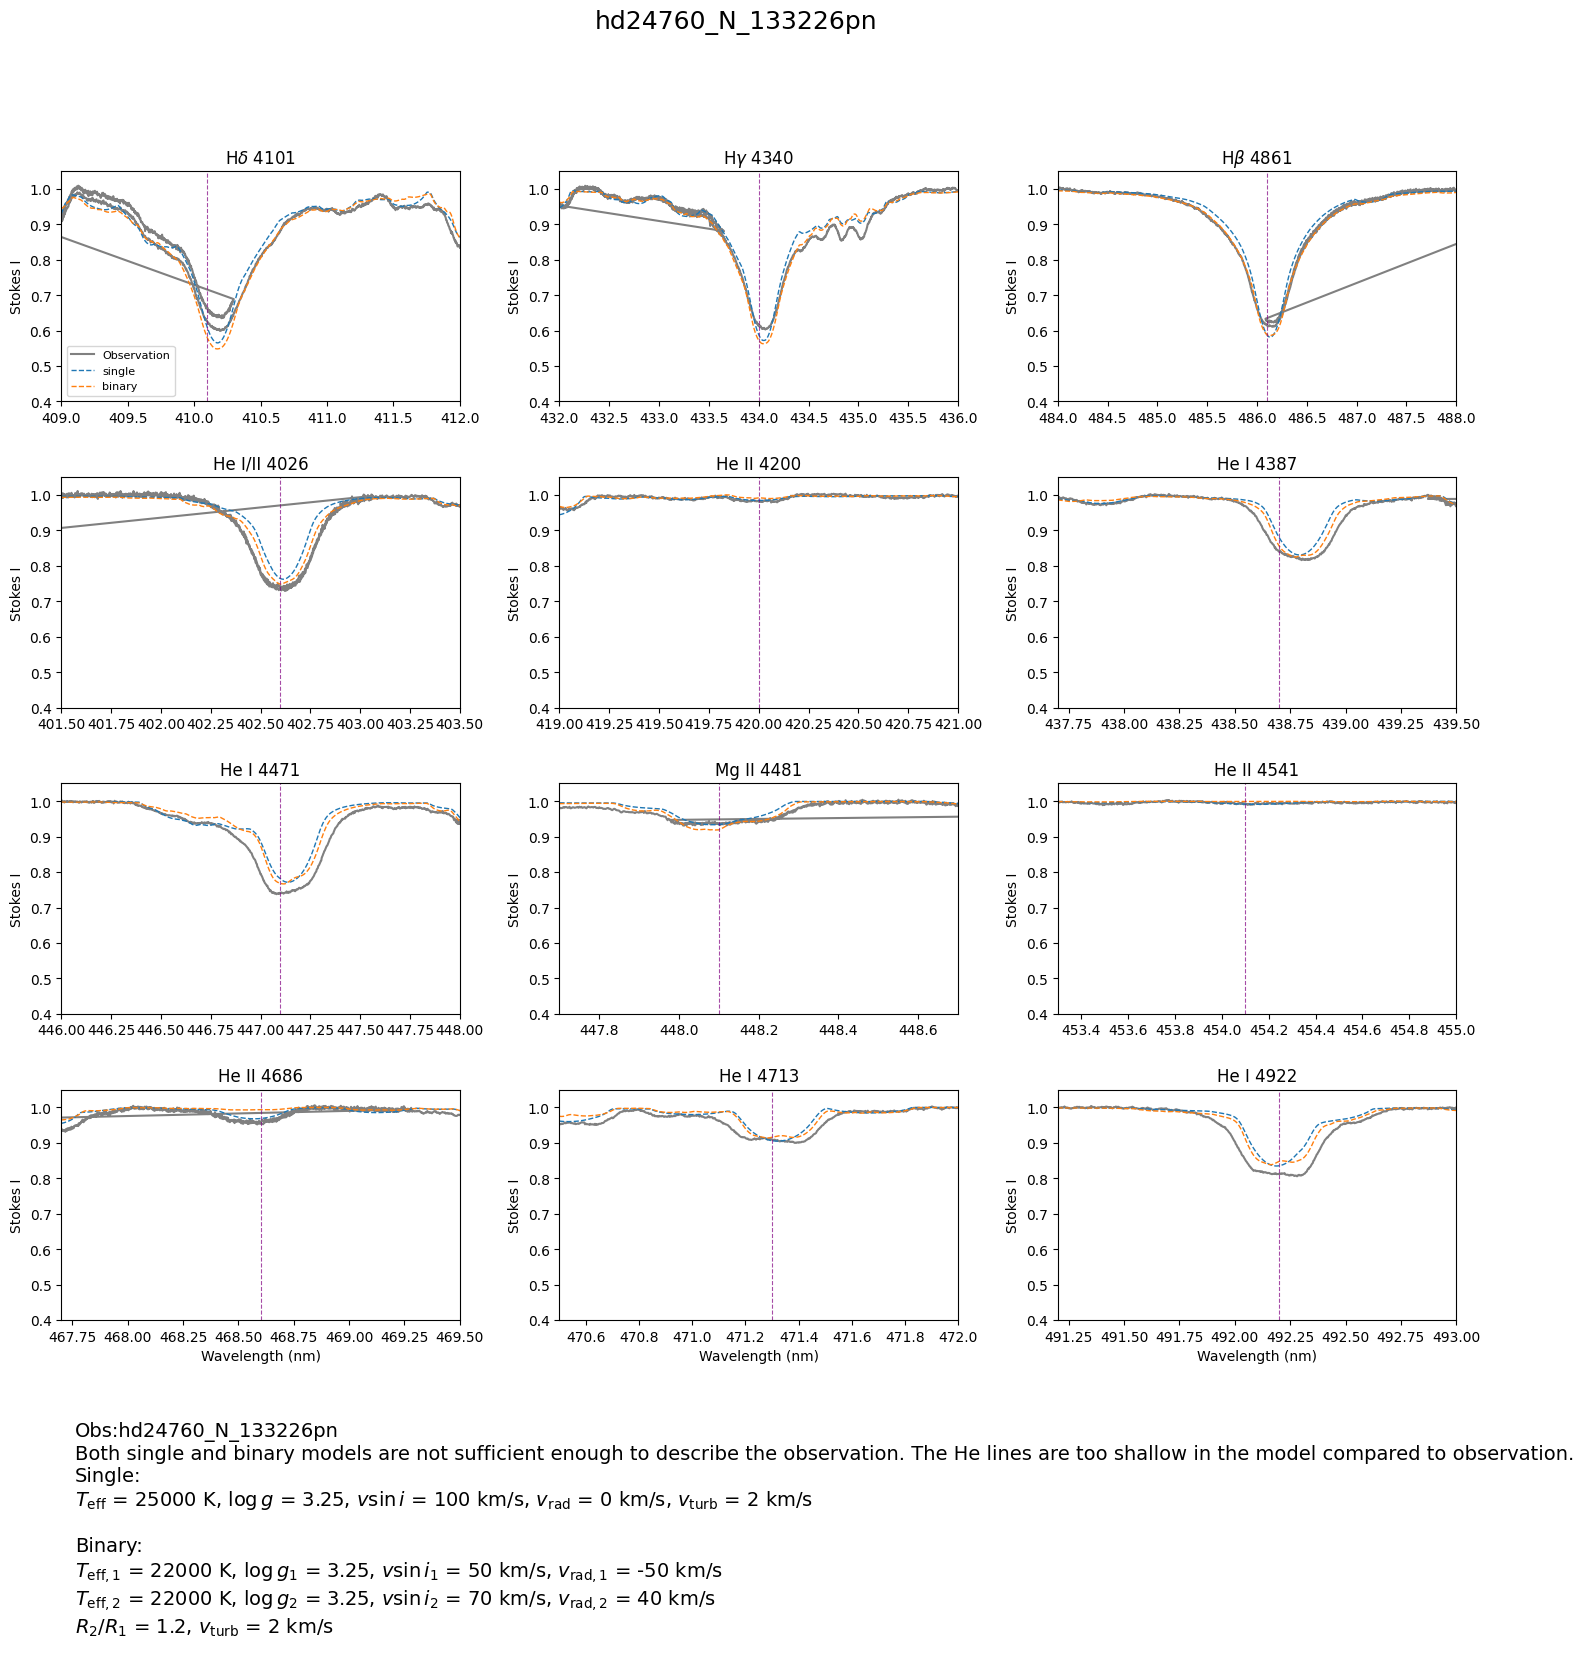

In [32]:
# =========================
# LINE DIAGNOSTIC PLOT
# =========================

H_lines = [(409,412,410.1,r"H$\delta$ 4101"), (432,436,434.0,r"H$\gamma$ 4340"),
           (484,488,486.1,r"H$\beta$ 4861")]

He_lines = [(401.5,403.5,402.6,"He I/II 4026"), (419,421,420.0,"He II 4200"),
            (437.7,439.5,438.7,"He I 4387"), (446,448,447.1,"He I 4471"),
            (447.7,448.7,448.1,"Mg II 4481"), (453.3,455,454.1,"He II 4541"),
            (467.7,469.5,468.6,"He II 4686"), (470.5,472,471.3,"He I 4713"),
            (491.2,493,492.2,"He I 4922")]

all_lines = H_lines + He_lines

fig = plt.figure(figsize=(18,18))
gs = GridSpec(5,3,figure=fig,height_ratios=[1,1,1,1,0.7],
              hspace=0.35,wspace=0.25)

ax = [fig.add_subplot(gs[i,j]) for i in range(4) for j in range(3)]
ax_text = fig.add_subplot(gs[4,:])

for a,(xmin,xmax,wl,line) in zip(ax,all_lines):
    a.plot(spec1.wl,spec1.specI,color="0.5",lw=1.5,label="Observation")
    a.plot(single_model.wl,single_model.specI,lw=1,ls="--",label="single")
    a.plot(binary_model.wl,binary_model.specI,lw=1,ls="--",label="binary")
    a.axvline(wl,color="purple",ls="--",lw=0.8,alpha=0.7)
    a.set_xlim(xmin,xmax); a.set_ylim(0.4,1.05)
    a.set_title(line); a.set_ylabel("Stokes I")

for a in ax[-3:]: a.set_xlabel("Wavelength (nm)")

ax[0].legend(fontsize=8)

ax_text.axis("off")
ax_text.text(0.01,0.98,notes,va="top",fontsize=14,
             wrap=True,transform=ax_text.transAxes)

fig.suptitle(obsname,fontsize=18,y=0.97)
plt.savefig(obsname+'_SingleModel.pdf')
plt.show()